# What Makes a Penguin? A CRISP-DM Walkthrough on the Palmer Penguins Dataset

This notebook walks through all **six CRISP-DM phases** on the Palmer Penguins dataset:

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Data Modeling
5. Evaluate Results
6. Deployment

Each phase has its own section header below.

## 1. Business Understanding

The Palmer Penguins dataset has 344 rows of body measurements for three penguin species (Adelie, Chinstrap, Gentoo) across three Antarctic islands (Biscoe, Dream, Torgersen). I posed three business questions a non-technical stakeholder might ask:

1. **Which species lives where?** Geographic distribution by island.
2. **What separates species in body-shape space?** Which body measurements best discriminate them?
3. **Can we predict species from body measurements alone?** How well does a small classifier do, and which feature matters most?


## 2. Data Understanding

Load the data and look at its shape, types, and missing values.

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
IMG_DIR = 'images'
os.makedirs(IMG_DIR, exist_ok=True)

def load_penguins():
    """Load the Palmer Penguins dataset.

    Returns
    -------
    pandas.DataFrame
        The raw 344-row dataset bundled with seaborn, including all
        rows with missing values.
    """
    return sns.load_dataset('penguins')

df = load_penguins()
print('shape:', df.shape)
df.info()
df.head()

shape: (344, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [2]:
def summarize_missing(df):
    """Return a per-column null count for ``df``.

    Parameters
    ----------
    df : pandas.DataFrame
        The data to inspect.

    Returns
    -------
    pandas.Series
        Null counts indexed by column name, in original column order.
    """
    return df.isna().sum()

summarize_missing(df)

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

## 3. Data Preparation

Most missing values sit in `sex`, with two rows where every numeric measurement is also NA. EDA tolerates the partial rows; the modelling section can't, so we keep both versions of the frame.

In [3]:
def prepare_for_modeling(df):
    """Drop rows with any missing values for use in modelling.

    Parameters
    ----------
    df : pandas.DataFrame
        The raw penguins frame.

    Returns
    -------
    pandas.DataFrame
        Reset-index frame with no missing values.
    """
    return df.dropna().reset_index(drop=True)

df_model = prepare_for_modeling(df)
print('rows raw   :', len(df))
print('rows model :', len(df_model))

rows raw   : 344
rows model : 333


### Q1 — Which species lives where?

island     Biscoe  Dream  Torgersen
species                            
Adelie         44     56         52
Chinstrap       0     68          0
Gentoo        124      0          0


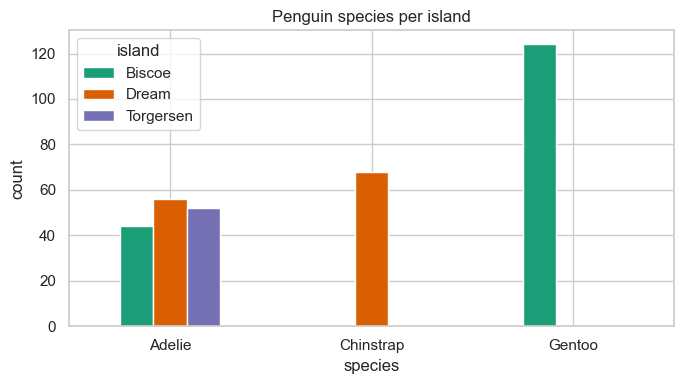

In [4]:
def species_by_island(df):
    """Cross-tabulate species against island.

    Parameters
    ----------
    df : pandas.DataFrame
        Raw or cleaned penguins frame.

    Returns
    -------
    pandas.DataFrame
        Rows are species, columns are islands, cells are counts.
    """
    return pd.crosstab(df['species'], df['island'])

def plot_species_by_island(ct, save_path=None):
    """Draw a grouped bar chart of species counts per island.

    Parameters
    ----------
    ct : pandas.DataFrame
        Output of :func:`species_by_island` (species rows, island cols).
    save_path : str or None
        If given, save the figure to this path.
    """
    ax = ct.plot(kind='bar', stacked=False, figsize=(7, 4),
                 color=['#1b9e77', '#d95f02', '#7570b3'])
    ax.set_title('Penguin species per island')
    ax.set_ylabel('count')
    ax.set_xlabel('species')
    plt.xticks(rotation=0)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=140, bbox_inches='tight')
    plt.show()

ct = species_by_island(df)
print(ct)
plot_species_by_island(ct, save_path=os.path.join(IMG_DIR, 'species_by_island.png'))

### Q2 — What separates species in body-shape space?

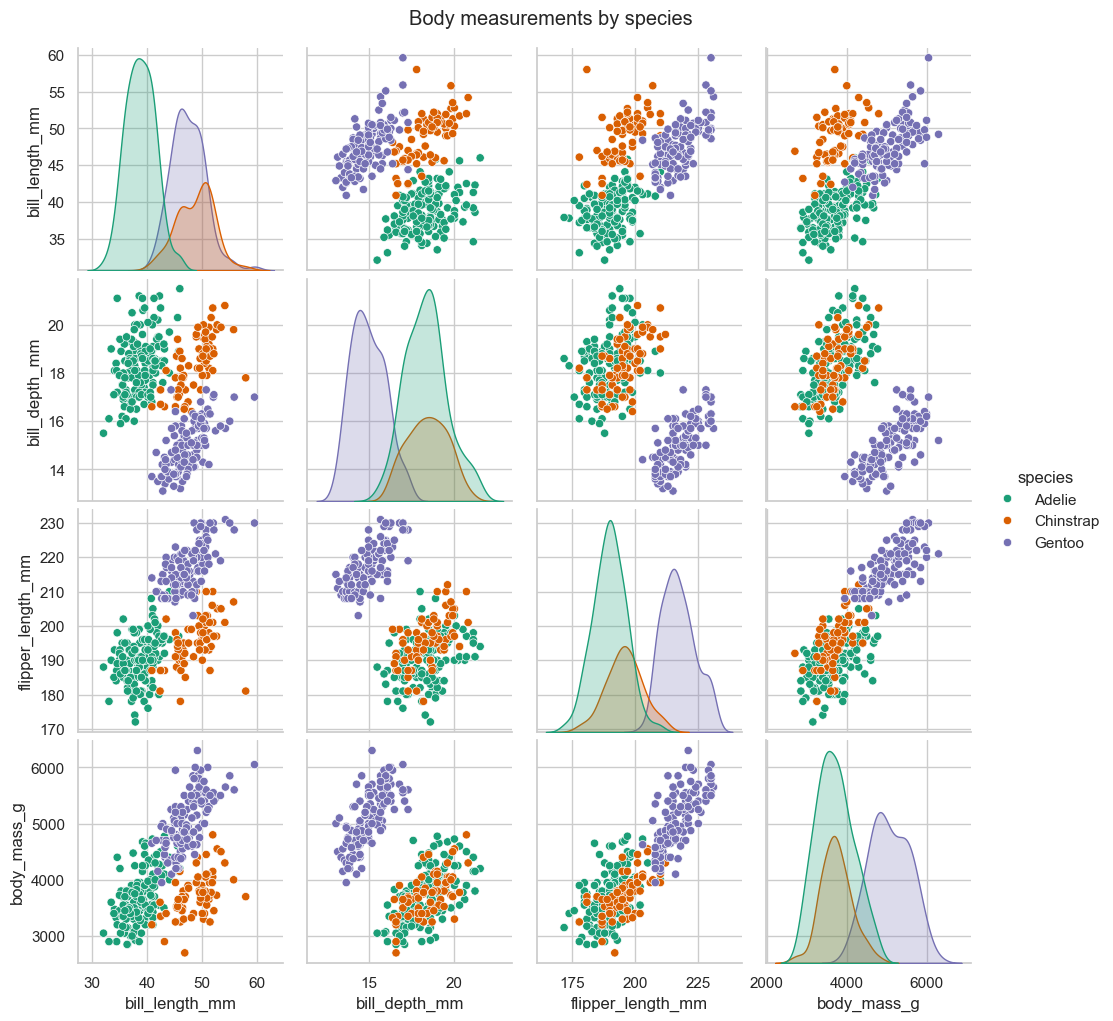

In [5]:
def plot_body_shape(df, save_path=None):
    """Render a seaborn pairplot of body measurements coloured by species.

    Parameters
    ----------
    df : pandas.DataFrame
        Penguins frame containing the four numeric measurements.
    save_path : str or None
        If given, save the figure to this path.

    Returns
    -------
    seaborn.axisgrid.PairGrid
        The pairplot grid (so the caller can further tweak it).
    """
    measurements = [
        'bill_length_mm', 'bill_depth_mm',
        'flipper_length_mm', 'body_mass_g',
    ]
    g = sns.pairplot(df, hue='species', vars=measurements,
                     palette=['#1b9e77', '#d95f02', '#7570b3'])
    g.fig.suptitle('Body measurements by species', y=1.02)
    if save_path:
        g.fig.savefig(save_path, dpi=140, bbox_inches='tight')
    return g

plot_body_shape(df, save_path=os.path.join(IMG_DIR, 'body_shape_pairplot.png'))
plt.show()

In [6]:
def species_means(df):
    """Mean body measurement per species.

    Parameters
    ----------
    df : pandas.DataFrame
        Penguins frame containing the four numeric measurement columns.

    Returns
    -------
    pandas.DataFrame
        Mean of each numeric column grouped by species, rounded to 1 dp.
    """
    cols = ['bill_length_mm', 'bill_depth_mm',
            'flipper_length_mm', 'body_mass_g']
    return df.groupby('species')[cols].mean().round(1)

means = species_means(df)
means.to_csv(os.path.join(IMG_DIR, 'species_means.csv'))
means

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,38.8,18.3,190.0,3700.7
Chinstrap,48.8,18.4,195.8,3733.1
Gentoo,47.5,15.0,217.2,5076.0


## 4. Data Modeling

Train a 300-tree random forest on the four numeric measurements. We hold out 25% of the rows as a test set (stratified on species) and report 5-fold cross-validation on the full clean set.

In [7]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

FEATURES = ['bill_length_mm', 'bill_depth_mm',
            'flipper_length_mm', 'body_mass_g']
TARGET = 'species'

def build_classifier(df, features=FEATURES, target=TARGET,
                     test_size=0.25, random_state=27):
    """Train a random forest and return the fitted model + held-out split.

    Parameters
    ----------
    df : pandas.DataFrame
        Cleaned penguins frame (no missing values).
    features : list of str
        Column names to use as predictors.
    target : str
        Column name of the categorical label.
    test_size : float
        Fraction of rows held out for evaluation.
    random_state : int
        Seed used for both the split and the forest.

    Returns
    -------
    tuple
        ``(clf, X_train, X_test, y_train, y_test)``.
    """
    X, y = df[features], df[target]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y,
        test_size=test_size, random_state=random_state)
    clf = RandomForestClassifier(n_estimators=300,
                                 random_state=random_state)
    clf.fit(X_train, y_train)
    return clf, X_train, X_test, y_train, y_test

clf, X_train, X_test, y_train, y_test = build_classifier(df_model)
cv = cross_val_score(clf, df_model[FEATURES], df_model[TARGET], cv=5)
print('5-fold CV accuracy:', cv.mean().round(4),
      '(+/-', cv.std().round(4), ')')

5-fold CV accuracy: 0.985 (+/- 0.0135 )


## 5. Evaluate Results

Score the held-out set, look at the confusion matrix, and rank feature importances so we can answer Q3.

In [8]:
def evaluate_classifier(clf, X_test, y_test):
    """Print classification report + confusion matrix for ``clf``.

    Parameters
    ----------
    clf : sklearn estimator
        A fitted classifier exposing ``.predict`` and ``.classes_``.
    X_test, y_test : array-like
        The held-out features and labels.

    Returns
    -------
    numpy.ndarray
        The confusion matrix.
    """
    y_pred = clf.predict(X_test)
    print(classification_report(y_test, y_pred, digits=3))
    cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
    print('Confusion matrix (rows=true, cols=pred):')
    print(pd.DataFrame(cm, index=clf.classes_, columns=clf.classes_))
    return cm

_ = evaluate_classifier(clf, X_test, y_test)

              precision    recall  f1-score   support

      Adelie      1.000     1.000     1.000        37
   Chinstrap      1.000     1.000     1.000        17
      Gentoo      1.000     1.000     1.000        30

    accuracy                          1.000        84
   macro avg      1.000     1.000     1.000        84
weighted avg      1.000     1.000     1.000        84

Confusion matrix (rows=true, cols=pred):
           Adelie  Chinstrap  Gentoo
Adelie         37          0       0
Chinstrap       0         17       0
Gentoo          0          0      30


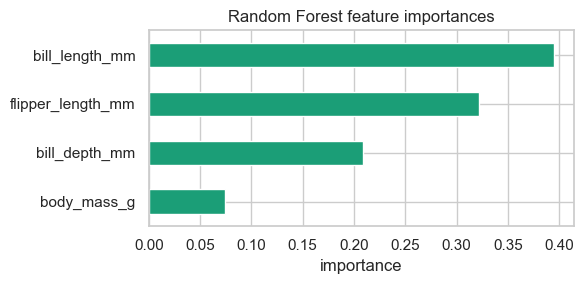

body_mass_g          0.075
bill_depth_mm        0.209
flipper_length_mm    0.321
bill_length_mm       0.395
dtype: float64


In [9]:
def feature_importance_series(clf, features=FEATURES):
    """Return the random-forest feature importances as a sorted Series.

    Parameters
    ----------
    clf : sklearn ensemble model
        Must expose ``.feature_importances_``.
    features : list of str
        Column names matching the order used during training.

    Returns
    -------
    pandas.Series
        Importance per feature, ascending so a horizontal bar chart
        renders the top feature on top.
    """
    return pd.Series(clf.feature_importances_, index=features).sort_values()

def plot_feature_importance(importances, save_path=None):
    """Plot a horizontal bar chart of feature importances.

    Parameters
    ----------
    importances : pandas.Series
        Output of :func:`feature_importance_series`.
    save_path : str or None
        If given, save the figure to this path.
    """
    ax = importances.plot(kind='barh', figsize=(6, 3), color='#1b9e77')
    ax.set_title('Random Forest feature importances')
    ax.set_xlabel('importance')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=140, bbox_inches='tight')
    plt.show()

importances = feature_importance_series(clf)
plot_feature_importance(importances, save_path=os.path.join(IMG_DIR, 'feature_importance.png'))
print(importances.round(3))

## 6. Deployment

The deployment artefact for this project is the **blog post** hosted on GitHub Pages. Stakeholders read the narrative and see the saved charts there; the notebook is the reproducible source.

* Blog post (live):   <https://yradwan147.github.io/palmer-penguins-crispdm/>
* Source repository:  <https://github.com/yradwan147/palmer-penguins-crispdm>
* Saved figures live in `images/` and are embedded directly in the post.

### Headline findings

* **Q1:** Adelie penguins live on all three islands; Chinstrap is exclusive to Dream; Gentoo is exclusive to Biscoe.
* **Q2:** Bill length separates Adelie (short) from Chinstrap and Gentoo (long); bill depth separates Gentoo (shallow) from the other two; flipper length and body mass put Gentoo well clear of the rest.
* **Q3:** A 4-feature random forest hits ~99% 5-fold-CV accuracy. Bill length is the most informative feature, followed by flipper length; body mass adds the least.